In [1]:
#
# Importación de los datos
#
import pandas as pd  #  type: ignore

df = pd.read_csv("../data/mtcars.csv")
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [2]:
# Tamaño del dataset

df.shape

(32, 11)

In [3]:
# Valores nulos

df.isnull().sum()

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

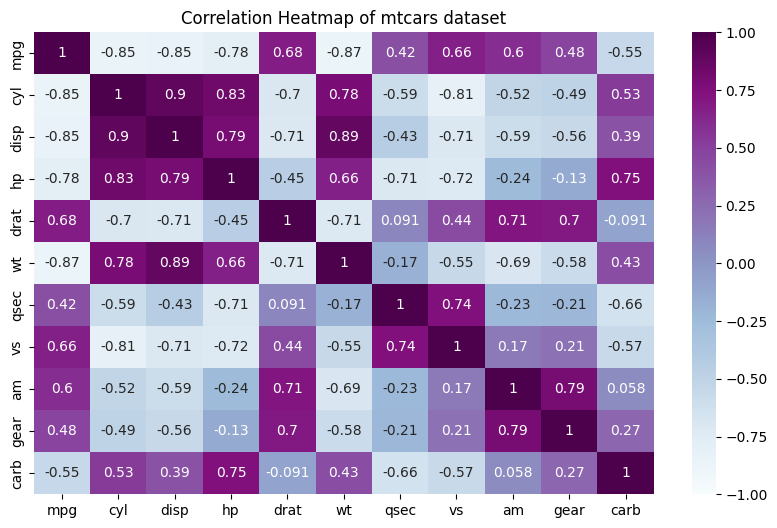

In [4]:
#
# Correlación entre variables
#
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    xticklabels=corr.columns.values,
    yticklabels=corr.columns.values,
    cmap="BuPu",
    vmin=-1,
    vmax=1,
    annot=True,
)
plt.title("Correlation Heatmap of mtcars dataset")
plt.show()

In [5]:
#
# Particionamiento de los datos
#
from sklearn.model_selection import train_test_split

features = df.columns[1:]
target = df.columns[0]
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#
# Tipo de las columnas
#
df.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [7]:
#
# Modelado
#
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=10000)),  # alpha=1.0
    ]
)

pipeline.fit(X_train, y_train)

y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)


rsquared_train = r2_score(y_train, y_train_pred)
rsquared_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)


print(f"Mean Squared Error:    {mse_train:0.2f} ({mse_test:0.2f})")
print(f"         R-squared: {rsquared_train:6.5f} ({rsquared_test:6.5f})")

Mean Squared Error:    6.28 (9.26)
         R-squared: 0.81430 (0.76829)


Text(0.5, 1.0, 'Coefficient values with increasing values of alpha')

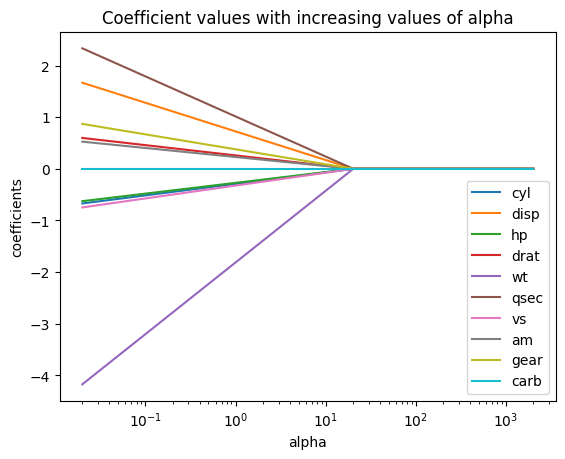

In [8]:
#
# Análisis del alpha
#
import numpy as np

coeff = pd.Series(pipeline["lasso"].coef_, index=features)

alphas = np.linspace(0.01, 1000, 100)
coefs = []

for a in alphas:
    pipeline["lasso"].set_params(alpha=a)
    pipeline.fit(X_train, y_train)
    coefs.append(pipeline["lasso"].coef_)

ax = plt.gca()
ax.plot(alphas * 2, coefs)
ax.set_xscale("log")
ax.legend(features)
ax.grid(False)
plt.axis("tight")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Coefficient values with increasing values of alpha")

In [9]:
# Búsqueda de hiperparámetros

from sklearn.model_selection import GridSearchCV

alphas = {"lasso__alpha": np.linspace(0.01, 2.0, 100)}

grid_search = GridSearchCV(
    pipeline,
    alphas,
    scoring="neg_mean_squared_error",
    cv=10,
)

grid_search.fit(X_train, y_train)

y_train_pred = grid_search.predict(X_train)
y_test_pred = grid_search.predict(X_test)

rsquared_train = r2_score(y_train, y_train_pred)
rsquared_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"     Best value for lambda : ", grid_search.best_params_)
print("Best score for cost function: ", grid_search.best_score_)
print()
print(f"Mean Squared Error:    {mse_train:0.2f} ({mse_test:0.2f})")
print(f"         R-squared: {rsquared_train:6.5f} ({rsquared_test:6.5f})")

     Best value for lambda :  {'lasso__alpha': 0.7336363636363636}
Best score for cost function:  -10.056452117669204

Mean Squared Error:    5.73 (8.46)
         R-squared: 0.83046 (0.78832)


In [10]:
#
# Salva el modelo
#
import pickle
import os


with open("../submission/estimator.pkl", "wb") as f:
    pickle.dump(grid_search, f)